# Influence of Beta_ab


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import Normalize
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.stats import pearsonr
from utils_mean_field import *
from script_mean_field_covid import *
# from utils_analysis_mf import *


main_path = "../"

sys.path.append(main_path + "PGM/source/")
sys.path.append(main_path + "PGM/utilities/")
import utilities, Proteins_utils, sequence_logo, plots_utils
sys.path.append(main_path + "covid/")
sys.path.append(main_path + "lattice/")
os.chdir(main_path + "covid/")

from global_variables import *
from utils_evaluate_seq import *
os.chdir('../mean_field_theory')
ab_names=list(ESCAPE_VECTORS.keys())


e:\ESCAPE_PATHS\covid\../PGM/source\numba_utilities.py:1124: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 2, 'F', False, aligned=True), Array(float32, 2, 'A', False, aligned=True))
  dmean_v_dw = np.dot(s1.T, V)
e:\ESCAPE_PATHS\covid\../PGM/source\numba_utilities.py:961: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 1, 'A', False, aligned=True), Array(float32, 2, 'A', False, aligned=True))
  mean_V = np.dot(weights, V) / sum_weights


Loaded 29 KD vectors


C:\Users\maria\AppData\Roaming\Python\Python312\site-packages\Bio\pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


# Order params

0.0: mean_f_free_ab_beta_ab_0_D_1
10.0: mean_f_free_ab_beta_ab_10_D_1
1.0: mean_f_free_ab_beta_ab_1_D_1
5.0: mean_f_free_ab_beta_ab_5_D_1
(21, 29)
0.0
(21, 29)
10.0
(21, 29)
1.0
(21, 29)
5.0


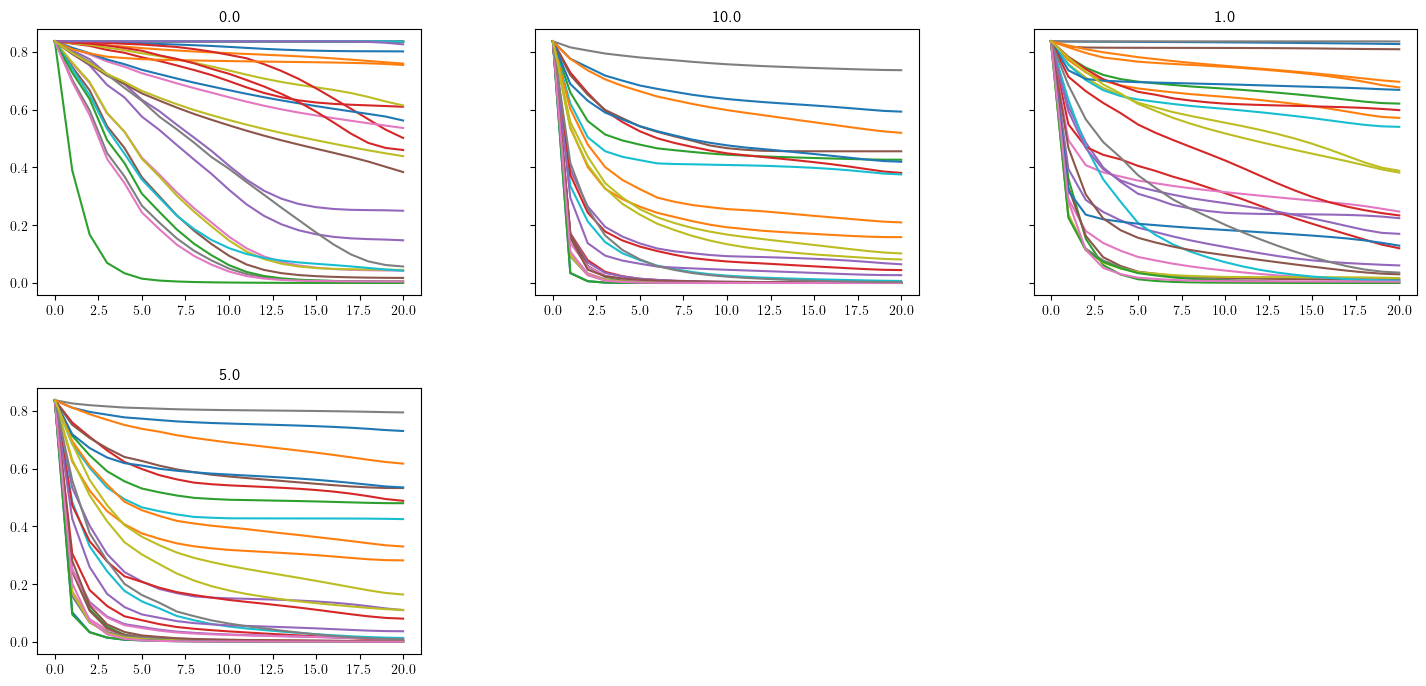

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import math


dir = 'results_scripts/covid_D_20/'

# Set condition sets
import os
import re

# Setup
BETA_ABs = [0,1,5, 10]
D=1

# Your extract_parameters function
def extract_parameters(path):
    beta_ab_match = re.search(r'beta_ab_(\d+(?:\.\d+)?)', path)
    D_match = re.search(r'D_(\d+)', path)
    return {
        "beta_ab": float(beta_ab_match.group(1)) if beta_ab_match else None,
        "D": int(D_match.group(1)) if D_match else None,
    }


# Get all folders
all_dirs = [d for d in os.listdir(dir) if os.path.isdir(os.path.join(dir, d))]

# Initialize lists
paths = []
labels = []

# Loop through each condition set and each condition
for d in all_dirs:
    params = extract_parameters(d)
    if (
        params["beta_ab"] in BETA_ABs and
        params["D"] == D 
    ):
        paths.append(d)
        labels.append(params["beta_ab"])

# Check: paths[i] corresponds to labels[i]
for p, l in zip(paths, labels):
    print(f"{l}: {p}")


import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import math
import os

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
import math

# LaTeX text settings
mpl.rcParams.update({
    "text.usetex": True,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 14
})

# Parameters
n_cols = 3
n_paths = len(labels)
n_rows = math.ceil(n_paths / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.8 * n_cols, 3.5 * n_rows), sharey=True)
axes = axes.flatten()
#force same y axis scale


for i, condition in enumerate(labels):
    ax = axes[i]

    # Load and compute mutation
    mopt = np.load(os.path.join(dir, paths[i], "mopt.npy")) [:,:29]
    #we plot 29 abs vs steps. Theire names are in ab_names
    print(mopt.shape)
    binding=np.exp(mopt)
    print(condition)

    T = mopt.shape[0] 
    steps = np.arange(0, T )

    # Plot
    ax.plot(steps, binding, label=r"$1 - q_t \cdot L$")
    ax.set_title(f"{condition}")


# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(pad=1.2)
plt.subplots_adjust(hspace=0.35, wspace=0.3)
plt.show()



In [3]:
L=None

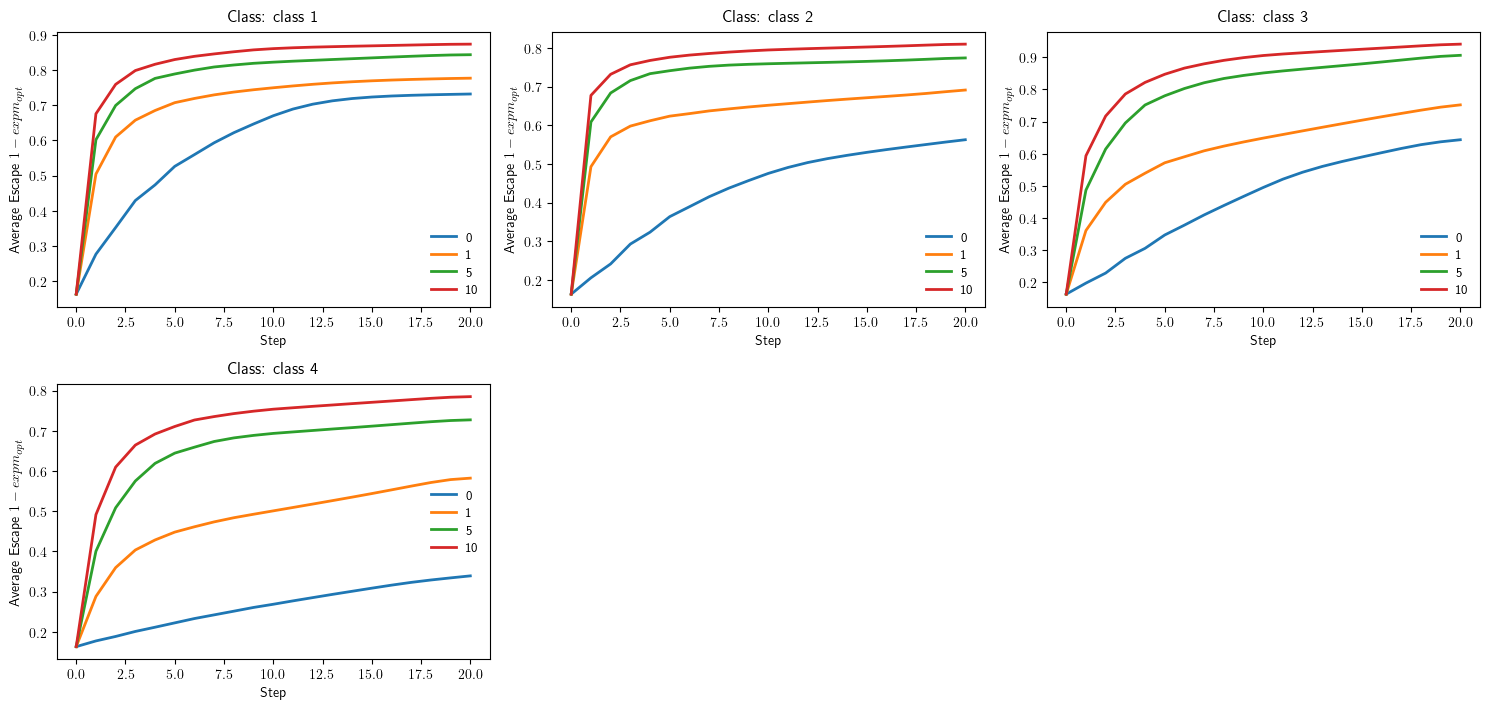

In [4]:
import pandas as pd

# --- config ---
dir = '../mean_field_theory/results_scripts/covid_D_20/'

# Ensure ab_names exists and aligns with mopt columns
ab_names = list(ESCAPE_VECTORS.keys())

# Load antibody → class mapping
ab_class_df = pd.read_csv("../covid/exp_data/bloom_ab_classification/ab_classification.csv")
ab_to_class = dict(zip(ab_class_df['condition'].astype(str), ab_class_df['condition_subtype'].astype(str)))

# Build class -> indices over ab_names
class_to_indices = {}
for i, ab in enumerate(ab_names):
    cls = ab_to_class.get(ab, None)
    if cls is None:
        continue
    class_to_indices.setdefault(cls, []).append(i)

classes = [c for c, idxs in class_to_indices.items() if len(idxs) > 0]
classes = sorted(classes)

# Collect per-condition time series: mean(L * mopt) per class over steps
per_condition_series = {}  # condition -> {class -> 1D array over steps}
for i, condition in enumerate(labels):
    # only plot selected conditions
  

    mopt = np.load(os.path.join(dir, paths[i], "mopt.npy"))[:, :len(ab_names)]  # [steps, n_abs]
    Lm = 1-np.exp(mopt)  # escape proxy

    series = {}
    for cls in classes:
        idx = class_to_indices[cls]
        cls_mean = Lm[:, idx].mean(axis=1)  # mean over antibodies in class
        series[cls] = cls_mean
    per_condition_series[condition] = series

# Plot: one subplot per antibody class, lines: WT vs BA1
n_classes = len(classes)
n_cols = 3 if n_classes >= 3 else n_classes
n_rows = int(math.ceil(n_classes / max(1, n_cols)))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.0 * n_cols, 3.6 * n_rows), squeeze=False)
axes = axes.reshape(n_rows, n_cols)

x_steps = None
for idx_cls, cls in enumerate(classes):
    r = idx_cls // n_cols
    c = idx_cls % n_cols
    ax = axes[r, c]

    for condition in BETA_ABs:
        if condition not in per_condition_series:
            continue
        y = per_condition_series[condition][cls]
        if x_steps is None:
            x_steps = np.arange(len(y))
        ax.plot(x_steps, y, label=condition, linewidth=2)

    ax.set_title(f"Class: {cls}", pad=8)
    ax.set_xlabel("Step")
    ax.set_ylabel(r"Average Escape $ 1-exp m_{opt}$")
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.grid(False)
    ax.legend(frameon=False, fontsize=9, loc="best")

# Hide any empty subplots
for k in range(n_classes, n_rows * n_cols):
    r = k // n_cols
    c = k % n_cols
    axes[r, c].axis("off")

fig.tight_layout()


4
0
6
2
3
4
2
2
8
3
17
14
12
7
7
0
7
0
0
0
0
6
0
0
0
0
0
0
0
1
0
0
1
1
3
2
1
0
0
0
0
0
0
0
1
1
0
0
0
0
0
1
14
0
6
11
1
0
2
0
0
0
0
0
18
0
0
0
0
0
0
1
2
0
0
2
2
7
3
3
0
0
1


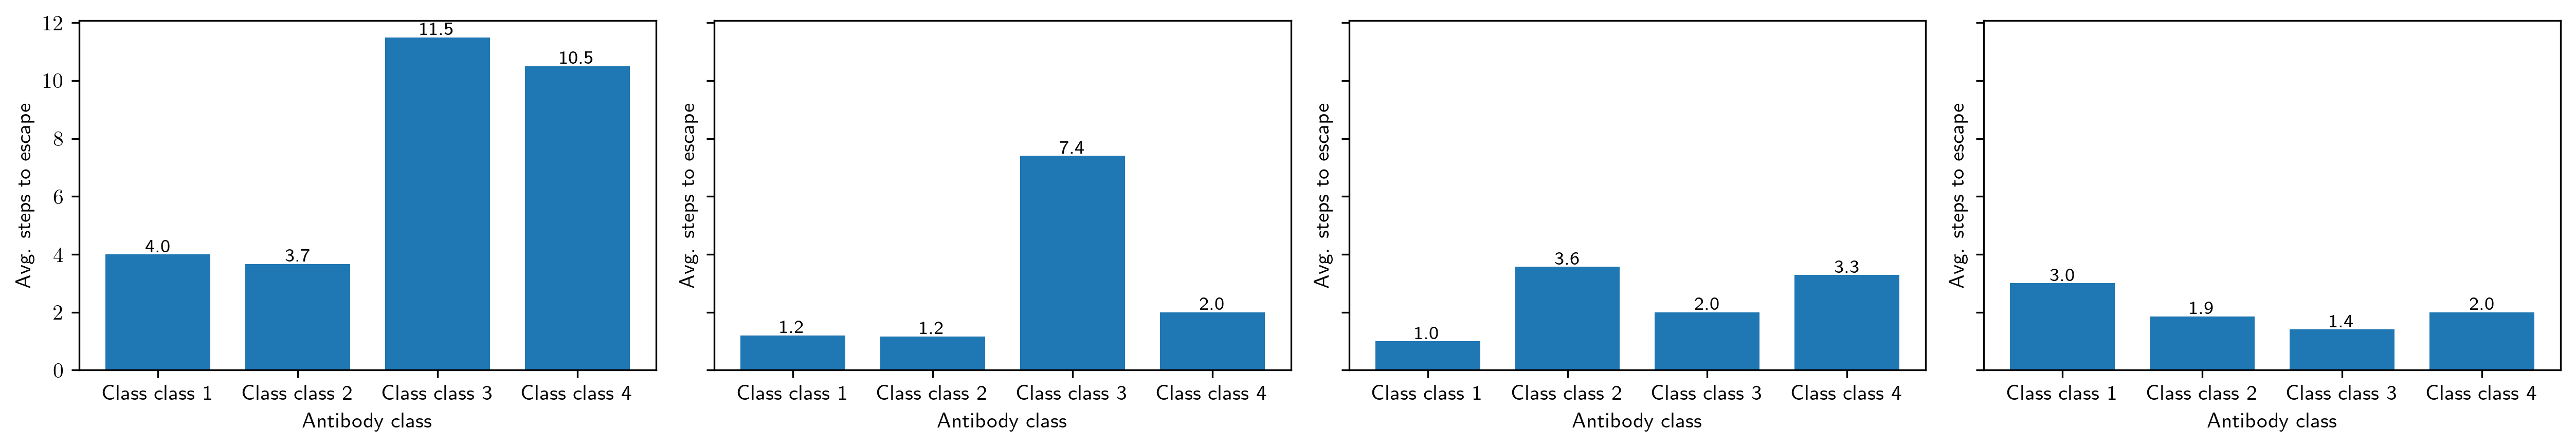

In [5]:
import os, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- Config ----------
TH = np.log(0.5)   # escape threshold applied to raw L * mopt
BG_ORDER = [c for c in BETA_ABs if c in per_condition_series]  # keep your order
# Helper: steps to first escape (raw series), or np.nan if never escapes
def steps_to_escape(raw_series, th=TH):
    """
    raw_series: shape (n_steps,) values of L*mopt for a single antibody over time.
    Returns the smallest t >= 1 such that raw_series[t] <= th,
    provided raw_series[0] > th (not escaped at start). Otherwise returns np.nan.
    """
    if raw_series[0] <= th:
        return 0  # already escaped at step 0 -> exclude per problem statement
    # Find first crossing at t>=1
    idx = np.where(raw_series[1:] <= th)[0]
    if idx.size == 0:
        return np.nan  # never escapes -> censor
    print(idx[0])

    return int(idx[0] + 1)

# ---------- Build class list (same as your figure) ----------
classes = sorted([c for c, idxs in class_to_indices.items() if len(idxs) > 0])
n_classes = len(classes)

# ---------- Compute mean steps to escape per background & class ----------
per_condition_steps_mean = {}    # condition -> {class -> mean steps}
per_condition_counts = {}        # condition -> {class -> number of antibodies used}

for i, condition in enumerate(labels):
    if condition not in BETA_ABs:
        continue

    # Load per-background mopt and form RAW = L * mopt (no 1 - exp transform)
    mopt = np.load(os.path.join(dir, paths[i], "mopt.npy"))[:, :len(ab_names)]  # [steps, n_abs]
    RAW =  mopt

    means = {}
    counts = {}
    for cls in classes:
        idxs = class_to_indices[cls]
        # steps-to-escape for each antibody in this class
        steps_list = [steps_to_escape(RAW[:, j]) for j in idxs]
        steps_arr = np.array(steps_list, dtype=float)
        # keep only finite values (exclude NaN: escaped at t=0 or never escaped)
        valid = steps_arr[np.isfinite(steps_arr)]
        means[cls] = float(valid.mean()) if valid.size > 0 else np.nan
        counts[cls] = int(valid.size)
    per_condition_steps_mean[condition] = means
    per_condition_counts[condition] = counts

# ---------- Plot: one subplot per background ----------
n_bg = len(BG_ORDER)
fig, axes = plt.subplots(1, n_bg, figsize=(4.2 * n_bg, 3.0), squeeze=False, sharey=True, dpi=300)
axes = axes[0]

x = np.arange(n_classes)

for ax, condition in zip(axes, BG_ORDER):
    means = per_condition_steps_mean[condition]
    counts = per_condition_counts[condition]
    heights = [means.get(cls, np.nan) for cls in classes]

    bars = ax.bar(x, heights, width=0.75, edgecolor="none")
    # ax.set_title(f"{condition}", pad=8)
    ax.set_xticks(x)
    ax.set_xticklabels([f"Class {c}" for c in classes])
    ax.set_ylabel("Avg. steps to escape")
    ax.set_xlabel("Antibody class")
    # no grid (per your preference)
    # for spine in ("top","right"):
    #     ax.spines[spine].set_visible(False)

    # Annotate bars with mean ± count used
    for xi, b, cls in zip(x, bars, classes):
        h = b.get_height()
        if np.isfinite(h):
            ax.text(xi, h - 0.05, f"{h:.1f}",
                    ha="center", va="bottom", fontsize=9)

fig.tight_layout()
plt.show()


In [6]:
TH

-0.6931471805599453

<>:96: SyntaxWarning: invalid escape sequence '\%'
<>:96: SyntaxWarning: invalid escape sequence '\%'
C:\Users\maria\AppData\Local\Temp\ipykernel_28780\1217293775.py:96: SyntaxWarning: invalid escape sequence '\%'
  ax.set_ylabel("Percentage of Abs escaped (\%)")


Calculating escape percentages for 4 conditions...
Calculation complete. Plotting...


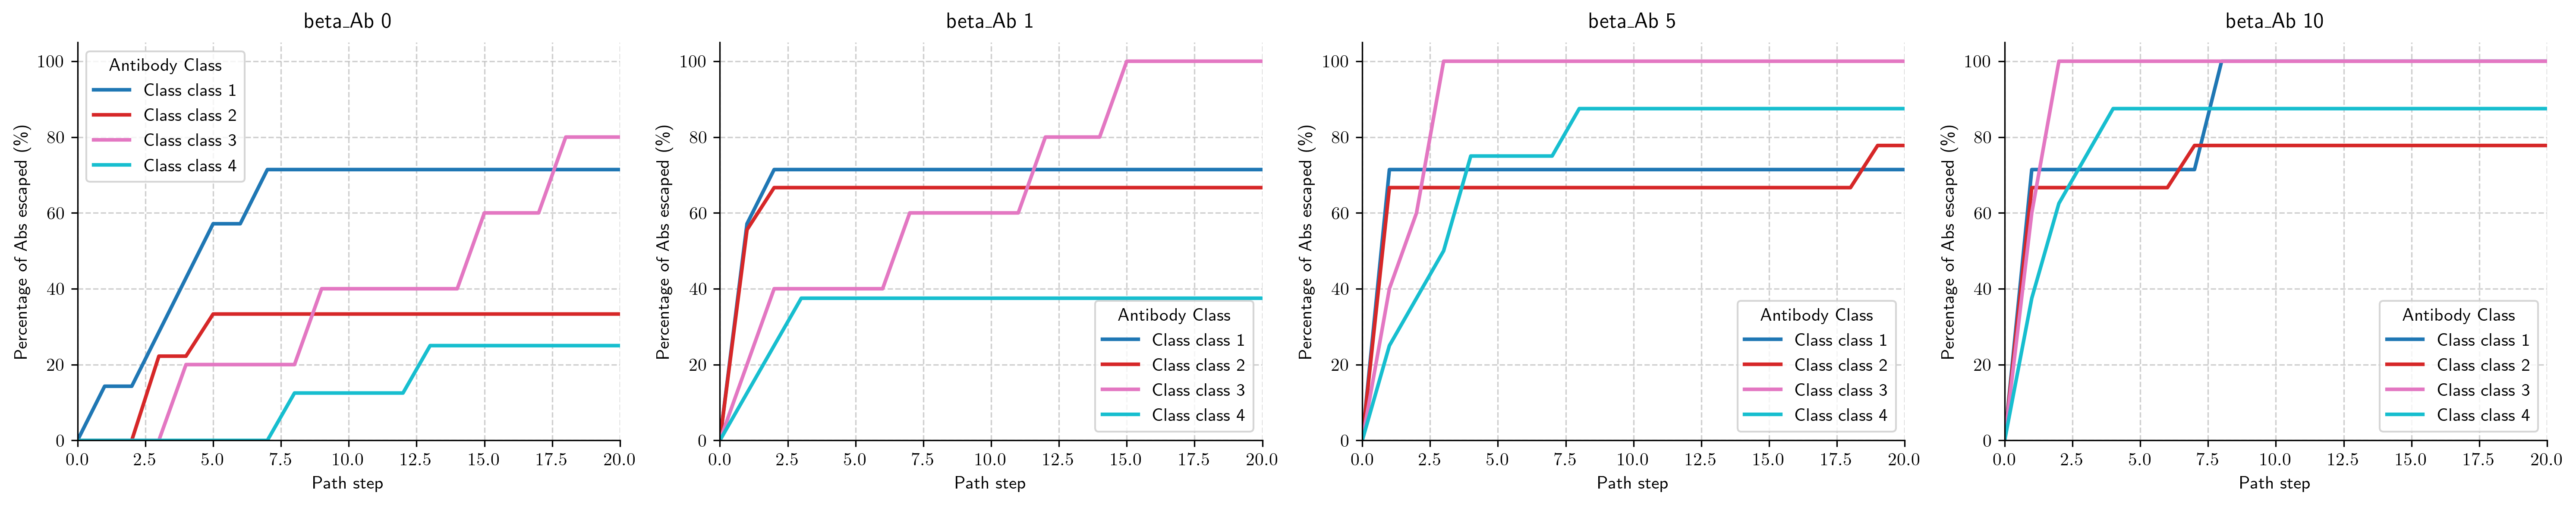

In [7]:
import os, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import matplotlib.cm as cm # Added for line colors
# ---------- Config ----------
# Threshold for escape (same as your code)
TH = np.log(0.5)
# Order of conditions to plot (same as your code)
BG_ORDER = [c for c in BETA_ABs if c in per_condition_series]
# Get antibody classes (same as your code)
classes = sorted([c for c, idxs in class_to_indices.items() if len(idxs) > 0])
n_classes = len(classes)

# ---------- Compute Percentage Escaped Over Time ----------
# This new dictionary will store the time series data
# Format: { condition -> { class -> np.array([%_t0, %_t1, ...]) } }
per_condition_escape_pct = {}
n_steps = 0 # Will be set from the first file loaded

# Helper dict to find the index 'i' for a given condition name
label_to_index = {label: i for i, label in enumerate(labels)}
# Get the (name, index) pairs for only the conditions we want to plot
condition_indices = [(bg, label_to_index[bg]) for bg in BG_ORDER if bg in label_to_index]

print(f"Calculating escape percentages for {len(condition_indices)} conditions...")

for condition, i in condition_indices:
    # Load per-background mopt and form RAW = L * mopt (same as your code)
    mopt = np.load(os.path.join(dir, paths[i], "mopt.npy"))[:, :len(ab_names)] # [steps, n_abs]
    RAW =  mopt

    # Store n_steps (assumes all mopt files have same number of steps)
    if n_steps == 0:
        n_steps = mopt.shape[0]

    class_pct_series = {}
    for cls in classes:
        idxs = class_to_indices[cls]
        total_in_class = len(idxs)

        if total_in_class == 0:
            # No antibodies in this class, store NaNs
            class_pct_series[cls] = np.full(n_steps, np.nan)
            continue

        # Get the raw data for just this class
        # Shape: (n_steps, total_in_class)
        class_raw_data = RAW[:, idxs]

        # Check for escape (<= TH) at each step.
        # escaped_bools shape: (n_steps, total_in_class)
        escaped_bools = (class_raw_data <= TH)

        # Count how many are escaped at each step (sum over the abs axis)
        # n_escaped_at_step shape: (n_steps,)
        n_escaped_at_step = np.sum(escaped_bools, axis=1)

        # Convert to percentage
        pct_escaped_at_step = (n_escaped_at_step / total_in_class) * 100.0

        class_pct_series[cls] = pct_escaped_at_step

    per_condition_escape_pct[condition] = class_pct_series

print("Calculation complete. Plotting...")

# ---------- Plot: one subplot per background ----------
n_bg = len(BG_ORDER)
fig, axes = plt.subplots(1, n_bg, figsize=(5 * n_bg, 4.0), squeeze=False, sharey=False, dpi=300)
axes = axes[0] # Get the 1D array of axes

# X-axis is the path steps
x_steps = np.arange(n_steps)
# Generate colors for the lines
colors = plt.colormaps['tab10'](np.linspace(0, 1, n_classes))

for i, (ax, condition) in enumerate(zip(axes, BG_ORDER)):
    if condition not in per_condition_escape_pct:
        ax.set_title(f"{condition}\n(No data)")
        continue

    class_series_map = per_condition_escape_pct[condition]

    # Plot one line for each antibody class
    for j, cls in enumerate(classes):
        y_pct = class_series_map[cls]
        ax.plot(x_steps, y_pct, label=f"Class {cls}", color=colors[j], linewidth=2)

    ax.set_title(f"beta_Ab {condition}", pad=8)
    ax.set_xlabel("Path step")
    ax.set_ylim(0, 105) # Y-axis from 0% to 100% (with 5% padding)
    ax.set_xlim(left=0, right=n_steps - 1)

    # Only add Y-axis label to the very first plot
    ax.set_ylabel("Percentage of Abs escaped (\%)")

    ax.legend(title="Antibody Class")
    # Add light gridlines for readability
    ax.grid(True, linestyle='--', alpha=0.6)
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


fig.tight_layout()
plt.show()


Calculating mean binding for 4 conditions...
Calculation complete. Plotting...


C:\Users\maria\AppData\Local\Temp\ipykernel_28780\1990394716.py:65: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10')(np.linspace(0, 1, n_classes))


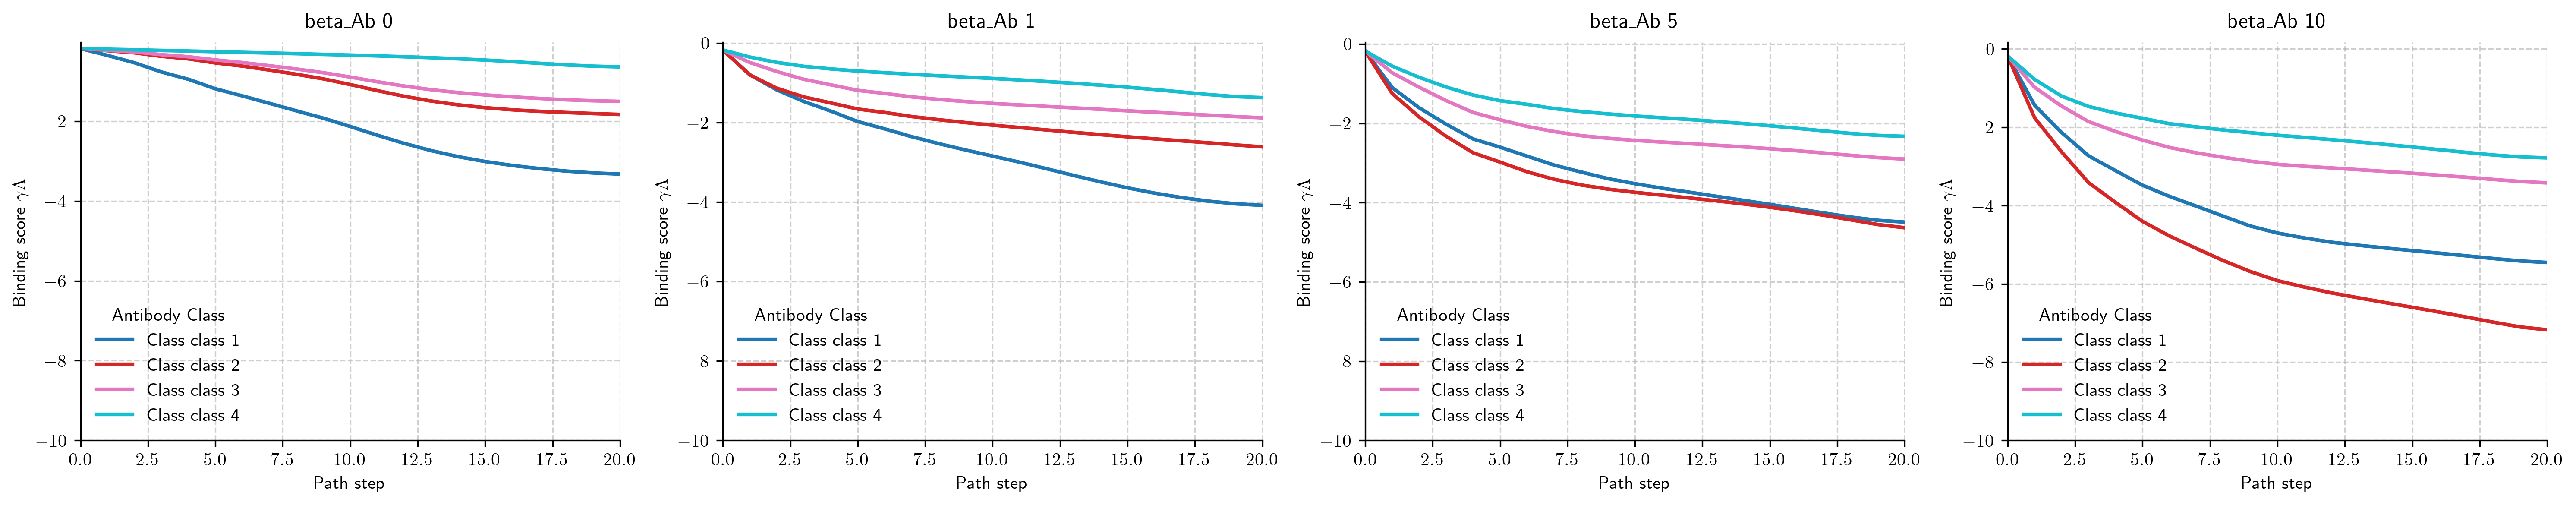

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ---------- Config ----------
# Order of conditions to plot
BG_ORDER = [c for c in BETA_ABs if c in per_condition_series]
# Get antibody classes
classes = sorted([c for c, idxs in class_to_indices.items() if len(idxs) > 0])
n_classes = len(classes)

# ---------- Compute Mean Binding Over Time ----------
# Store time series data: { condition -> { class -> np.array([val_t0, val_t1, ...]) } }
per_condition_mean_binding = {}
n_steps = 0 

# Helper dict to find the index 'i' for a given condition name
label_to_index = {label: i for i, label in enumerate(labels)}
condition_indices = [(bg, label_to_index[bg]) for bg in BG_ORDER if bg in label_to_index]

print(f"Calculating mean binding for {len(condition_indices)} conditions...")

for condition, i in condition_indices:
    # Load per-background mopt and form RAW = L * mopt
    # RAW contains the log binding values
    mopt = np.load(os.path.join(dir, paths[i], "mopt.npy"))[:, :len(ab_names)] # [steps, n_abs]
    RAW = mopt

    if n_steps == 0:
        n_steps = mopt.shape[0]

    class_binding_series = {}
    for cls in classes:
        idxs = class_to_indices[cls]
        total_in_class = len(idxs)

        if total_in_class == 0:
            class_binding_series[cls] = np.full(n_steps, np.nan)
            continue

        # 1. Get the raw log-binding data for just this class
        # Shape: (n_steps, total_in_class)
        class_log_data = RAW[:, idxs]

        # 2. Exponentiate to get actual binding (linear space)
        class_linear_data =class_log_data

        # 3. Compute the mean binding across antibodies in this class at each step
        # Shape: (n_steps,)
        avg_binding_at_step = np.mean(class_linear_data, axis=1)

        class_binding_series[cls] = avg_binding_at_step

    per_condition_mean_binding[condition] = class_binding_series

print("Calculation complete. Plotting...")

# ---------- Plot: one subplot per background ----------
n_bg = len(BG_ORDER)
fig, axes = plt.subplots(1, n_bg, figsize=(5 * n_bg, 4.0), squeeze=False, sharey=False, dpi=300)
axes = axes[0] 

x_steps = np.arange(n_steps)
# Generate colors
colors = plt.cm.get_cmap('tab10')(np.linspace(0, 1, n_classes))

for i, (ax, condition) in enumerate(zip(axes, BG_ORDER)):
    if condition not in per_condition_mean_binding:
        ax.set_title(f"{condition}\n(No data)")
        continue


    class_series_map = per_condition_mean_binding[condition]

    # Plot one line for each antibody class
    for j, cls in enumerate(classes):
        y_vals = class_series_map[cls]
        ax.plot(x_steps, y_vals, label=f"Class {cls}", color=colors[j], linewidth=2)

    ax.set_title(f"beta_Ab {condition}", pad=8)
    ax.set_xlabel("Path step")
    
    # Dynamic Y-limits (start at 0, let top float)
    ax.set_ylim(bottom=-10)
    ax.set_xlim(left=0, right=n_steps - 1)

    ax.set_ylabel(r"Binding score $\gamma \Lambda$")

    ax.legend(title="Antibody Class", frameon=False)
    
    # Styling
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.tight_layout()
plt.show()


# Project

## Gisaid

In [9]:
# VOCS=Proteins_utils.load_FASTA("../covid/gisaid/sequences_vocs.fasta", drop_duplicates=False)
# VOCS = VOCS[:,BEGIN:-END]
# def extract_voc_names_from_fasta(fasta_path):
#     """
#     Extracts VOC names from a FASTA file.
#     Assumes each entry starts with a '>' followed by the VOC name.
#     """
#     voc_names = []
#     with open(fasta_path, 'r') as f:
#         for line in f:
#             if line.startswith('>'):
#                 voc_name = line[1:].strip()
#                 voc_names.append(voc_name)
#     return voc_names
# # List of VOCs to keep
# KEEP = {"BA.5", "XBB", "BQ.1.1", "WT", 'BA1'}

# # Extract all VOC names
# VOC_NAMES = extract_voc_names_from_fasta("../covid/gisaid/sequences_vocs.fasta")

# # Build mask for selected VOCs
# mask = [any(name.startswith(k) for k in KEEP) for name in VOC_NAMES]

# # Apply mask to names and sequences
# VOC_NAMES = [name for name, keep in zip(VOC_NAMES, mask) if keep]
# VOCS = VOCS[mask,:]
# rbd_dates = pd.read_csv('../covid/gisaid/rbd_dates.csv')
# rbd_dates=rbd_dates[rbd_dates['count']>1]
# print(rbd_dates.shape)
# rbd_dates['q05_date'] = pd.to_datetime(rbd_dates['q05_date'])
# seqs=Proteins_utils.load_FASTA('../covid/gisaid/rbd_dates_with_sequence.fasta')
# one_hot_seqs=np.array([one_hot_encode_concat(seq) for seq in seqs])
# # get indexes of 'count' >1
# indexes = rbd_dates[rbd_dates['count'] > 0].index
# rbd_dates = rbd_dates.iloc[indexes]
# print("rbd_dates", rbd_dates.shape)
# one_hot_seqs = one_hot_seqs[indexes]
# one_hot_seqs.shape


In [10]:
# wt_idx  = [i for i, n in enumerate(VOC_NAMES) if str(n).startswith("WT")]
# ba1_idx = [i for i, n in enumerate(VOC_NAMES) if str(n).startswith("BA1")]

# assert wt_idx and ba1_idx, "WT or BA1 not found in VOC_NAMES"

# wt_seq  = VOCS[wt_idx[0], :]   # 1D row for WT
# ba1_seq = VOCS[ba1_idx[0], :]  # 1D row for BA1

In [11]:
# folder='results_scripts/covid_D_20/mean_f_free_ab_beta_ab_10_D_40'
# # folder='results_scripts/mean_f_free_ab_beta_ab_0.2_D_21_ab_class1_2'
# mopt = np.load(f"{folder}/mopt.npy") [:,:29]*L
# folder0='results_scripts/covid_D_20/mean_f_free_ab_beta_ab_0_D_40'
# mopt0 = np.load(f"{folder0}/mopt.npy") [:,:29]*L
# folderba1='results_scripts/ba1_D_20/ba1_mean_f_free_ab_beta_ab_10_D_40'

# moptba1=np.load(f"{folderba1}/mopt.npy") [:,:29]*L
# mopt0.shape

In [12]:
# ab_names = list(ESCAPE_VECTORS.keys())
# L=178
# wab = np.zeros((L, 20, len(ab_names)))
# for idx, ab in enumerate(ab_names):
#     w_ab = ESCAPE_VECTORS[ab].reshape(L, 20)  # "no bias"
#     wab[:, :, idx] = w_ab
# #put last dimension first
# wab = np.moveaxis(wab, -1, 0)
# print("wab shape", wab.shape)
# wgamma_flat= wab.reshape(wab.shape[0], -1)

# wgamma_flat.shape

In [13]:
# def project_without_blas(one_hot_seqs, wgamma_flat):
#     """
#     Project each of N sequences (length-D) onto each of K axes,
#     without calling the BLAS-backed dot() function.
#     Returns an (N, K) array of projections.
#     """
#     N, D = one_hot_seqs.shape
#     K, D2 = wgamma_flat.shape
#     assert D == D2
    
    
#     # pre-allocate output
#     projections = np.empty((N, K), dtype=one_hot_seqs.dtype)
    
#     # for each axis, multiply elementwise and sum
#     for k in range(K):
#         # Broadcast: (N, D) * (D,) → (N, D), then sum over D → (N,)
#         projections[:, k] = (one_hot_seqs * wgamma_flat[k]).sum(axis=1)
    
#     return projections



In [14]:
# import numpy as np

# # 1. Define the alphabet your model was trained on (Standard 20 Amino Acids)
# AA_ALPHABET = "ACDEFGHIKLMNPQRSTVWY" 
# aa_to_int = {aa: i for i, aa in enumerate(AA_ALPHABET)}

# def one_hot_encode_concat(s):
#     """
#     One-hot encodes a sequence string into a flattened vector.
#     """
#     # Initialize matrix: Sequence Length x Alphabet Size
#     one_hot_matrix = np.zeros((len(s), len(AA_ALPHABET)), dtype=int)
    
#     for i, char in enumerate(s):
#         # FIX: Use the dictionary to map 'char' (str) to 'idx' (int)
#         if char in aa_to_int:
#             idx = aa_to_int[char]
#             one_hot_matrix[i, idx] = 1
#         else:
#             # Optional: Handle gaps/unknowns. 
#             # Currently ignores them (keeps row as all zeros).
#             pass 

#     # Flatten to match the shape expected by project_without_blas
#     return one_hot_matrix.flatten()

In [15]:
# def project_and_plot_2d(one_hot_seqs, wgamma_flat, dates_series):
#     """
#     Projects N×D sequences onto K antibody axes (wgamma_flat K×D),
#     PCA to 2D, colors points by average escape = mean(projection),
#     overlays WT/BA1 stars and MF trajectories (mopt, moptba1) on same plot.
#     Expects wt_seq, ba1_seq, mopt, moptba1 in scope.
#     """
#     # 1) projections and average escape
#     projections = project_without_blas(one_hot_seqs, wgamma_flat)   # (N,K)
#     avg_escape = projections.mean(axis=1)                           # (N,)

#     # 2) PCA to 2D
#     pca = PCA(n_components=2).fit(projections)
#     X_2d = pca.transform(projections)

#     # 3) WT and BA1 stars only
#     wt_proj  = project_without_blas(np.array([one_hot_encode_concat(wt_seq)]),  wgamma_flat)  # (1,K)
#     ba1_proj = project_without_blas(np.array([one_hot_encode_concat(ba1_seq)]), wgamma_flat)  # (1,K)
#     wt_2d  = pca.transform(wt_proj)   # (1,2)
#     ba1_2d = pca.transform(ba1_proj)  # (1,2)

#     vocs_proj= project_without_blas(np.array([one_hot_encode_concat(voc) for voc in VOCS]), wgamma_flat)
#     vocs_2d = pca.transform(vocs_proj)  # shape: (N, 2)

#     # 4) MF trajectories (use same PCA space)
#     mopt_2d    = pca.transform(mopt)     # (T,2)
#     moptba1_2d = pca.transform(moptba1)  # (T,2)

#     # 5) plot
#     fig, ax = plt.subplots(figsize=(3.5, 4), dpi=300)

#        # 1) make sure you convert your Series to plain Python datetimes
#     dates = pd.to_datetime(dates_series)
#     np_dates = dates.values.astype("datetime64[us]")
#     mdates_num = mdates.date2num(np_dates)


# # 3) set up a true Normalize object
#     norm = Normalize(vmin=mdates_num.min(), vmax=mdates_num.max())
#     sc = ax.scatter(
#         X_2d[:, 0],
#         X_2d[:, 1],
#         c=mdates_num,
#         cmap='viridis',
#         s=8,
#         edgecolors='none',
#         alpha=0.3,
        
#     )

#     # WT and BA1 stars
#     # for i, (x, y) in enumerate(vocs_2d):
#     #     ax.scatter(x, y, color='red', marker='*', s=100)
#     #     #boldly annotate each point with the corresponding VOC name
#     #     ax.annotate(VOC_NAMES[i], (x+(i%2-1)*1, y+((i+1)%2-1)*1), fontsize=8,#bold 
#     #     fontweight='bold', color='black', ha='right')

#     import matplotlib as mpl
#     import matplotlib.patheffects as pe

#     use_tex = mpl.rcParams.get("text.usetex", False)

#     for i, (x, y) in enumerate(vocs_2d):
#         ax.scatter(x, y, color='red', marker='*', s=120, zorder=3)

#         label = VOC_NAMES[i]
#         #replace BA1 with BA.1
#         label = label.replace("BA1", "BA.1")
#         if use_tex:
#             # Escape underscores etc. if needed:
#             label_tex = r'\textbf{' + label.replace('_', r'\_') + '}'
#             ax.annotate(label_tex, (x + (i%2-1)*1, y + ((i+1)%2-1)*1),
#                         fontsize=8, color='black', ha='right', zorder=4)
#         else:
#             ax.annotate(label, (x + (i%2-1)*1, y + ((i+1)%2-1)*1),
#                         fontsize=8, fontweight='bold', color='black',
#                         ha='right', zorder=4)


   
#     ax.scatter(wt_2d[0,0],  wt_2d[0,1],  color="blue", marker="*", s=220,
#            edgecolors="black", linewidths=0.8, zorder=10)
#     ax.scatter(ba1_2d[0,0], ba1_2d[0,1], color="blue", marker="*", s=220,
#            edgecolors="black", linewidths=0.8, zorder=10)

#     # ax.annotate('WT', (wt_2d[0, 0],  wt_2d[0, 1]+0.5), fontsize=10,#bold 
#     #     fontweight='black', color='black', ha='right')
#     # ax.annotate('BA.1', (ba1_2d[0, 0], ba1_2d[0, 1]+0.5), fontsize=10,#bold 
#     #     fontweight='black', color='black', ha='right')

#     # MF trajectories
#     ax.plot(mopt_2d[:, 0],    mopt_2d[:, 1],    color="tab:blue", ls="--", lw=1.8, label="MF start WT")
#     ax.plot(moptba1_2d[:, 0], moptba1_2d[:, 1], color="tab:red",  ls="--", lw=1.8, label="MF start BA.1")

#     # labels and frame
#     ax.set_xlabel("PC 1 antigenic profile", fontsize=14)
#     ax.set_ylabel("PC 2 antigenic profile", fontsize=14)
#     for spine in ax.spines.values():
#         spine.set_edgecolor("black")
#         spine.set_linewidth(0.8)

#     # colorbar for average escape
#     cbar = fig.colorbar(sc, ax=ax, orientation='vertical')
#     locator = mdates.AutoDateLocator()
#     formatter = mdates.ConciseDateFormatter(locator)
#     cbar.ax.yaxis_date()
#     cbar.ax.yaxis.set_major_locator(locator)
#     cbar.ax.yaxis.set_major_formatter(formatter)
#     cbar.set_label("Variant date of appearance", fontsize=16)

#     ax.legend(frameon=False, fontsize=10, loc="best")
#     plt.tight_layout()
#     plt.show()

# # call:
# project_and_plot_2d(one_hot_seqs, wgamma_flat, rbd_dates['q05_date'])


In [16]:
# def project_and_plot_2d(one_hot_seqs, wgamma_flat, _unused_dates_series=None):
#     """
#     Projects N×D sequences onto K antibody axes (wgamma_flat K×D),
#     PCA to 2D, colors points by average escape = mean(projection),
#     overlays WT/BA1 stars and MF trajectories (mopt, moptba1) on same plot.
#     Expects wt_seq, ba1_seq, mopt, moptba1 in scope.
#     """
#     # 1) projections and average escape
#     projections = project_without_blas(one_hot_seqs, wgamma_flat)   # (N,K)
#     avg_escape = projections.mean(axis=1)                           # (N,)

#     # 2) PCA to 2D
#     pca = PCA(n_components=2).fit(projections)
#     X_2d = pca.transform(projections)

#     # 3) WT and BA1 stars only
#     wt_proj  = project_without_blas(np.array([one_hot_encode_concat(wt_seq)]),  wgamma_flat)  # (1,K)
#     ba1_proj = project_without_blas(np.array([one_hot_encode_concat(ba1_seq)]), wgamma_flat)  # (1,K)
#     wt_2d  = pca.transform(wt_proj)   # (1,2)
#     ba1_2d = pca.transform(ba1_proj)  # (1,2)

#     vocs_proj= project_without_blas(np.array([one_hot_encode_concat(voc) for voc in VOCS]), wgamma_flat)
#     vocs_2d = pca.transform(vocs_proj)  # shape: (N, 2)

#     # 4) MF trajectories (use same PCA space)
#     mopt_2d    = pca.transform(mopt)     # (T,2)
#     moptba1_2d = pca.transform(moptba1)  # (T,2)

#     # 5) plot
#     fig, ax = plt.subplots(figsize=(5.5, 4))
#     norm = Normalize(vmin=-3, vmax=avg_escape.max())
#     sc = ax.scatter(
#         X_2d[:, 0], X_2d[:, 1],
#         c=avg_escape,
#         cmap="viridis",
#         norm=norm,
#         s=20,
#         edgecolors="none",
#         alpha=0.25,
#         label="Observed sequences"
#     )

#     # WT and BA1 stars
#     for i, (x, y) in enumerate(vocs_2d):
#         ax.scatter(x, y, color='red', marker='*', s=100)
#         #boldly annotate each point with the corresponding VOC name
#         ax.annotate(VOC_NAMES[i], (x+(i%2-1)*1, y+((i+1)%2-1)*1), fontsize=8,#bold 
#         fontweight='bold', color='black', ha='right')

#     ax.scatter(wt_2d[0, 0],  wt_2d[0, 1],  color="blue", marker="*", s=120)
#     ax.scatter(ba1_2d[0, 0], ba1_2d[0, 1], color="blue",  marker="*", s=120)
#     # ax.annotate('WT', (wt_2d[0, 0],  wt_2d[0, 1]+0.5), fontsize=10,#bold 
#     #     fontweight='black', color='black', ha='right')
#     # ax.annotate('BA.1', (ba1_2d[0, 0], ba1_2d[0, 1]+0.5), fontsize=10,#bold 
#     #     fontweight='black', color='black', ha='right')

#     # MF trajectories
#     ax.plot(mopt_2d[:, 0],    mopt_2d[:, 1],    color="tab:blue", ls="--", lw=1.8, label="MF start WT")
#     ax.plot(moptba1_2d[:, 0], moptba1_2d[:, 1], color="tab:red",  ls="--", lw=1.8, label="MF start BA.1")

#     # labels and frame
#     ax.set_xlabel("PC 1 antigenic profile", fontsize=12)
#     ax.set_ylabel("PC 2 antigenic profile", fontsize=12)
#     for spine in ax.spines.values():
#         spine.set_edgecolor("black")
#         spine.set_linewidth(1)

#     # colorbar for average escape
#     cbar = fig.colorbar(sc, ax=ax, orientation="vertical")
#     cbar.set_label("Log binding score", fontsize=11)

#     ax.legend(frameon=False, fontsize=10, loc="best")
#     plt.tight_layout()
#     plt.show()

# # call:
# project_and_plot_2d(one_hot_seqs, wgamma_flat, rbd_dates['q05_date'])

# Most probable sequence start WT

In [17]:
D=1

In [18]:
wt_seq=WT[BEGIN:-END]
dir = '../mean_field_theory/results_scripts/covid_D_20/'
paths=[f'mean_f_free_ab_beta_ab_0_D_{D}.npy', f'mean_f_free_ab_beta_ab_1_D_{D}.npy',    f'mean_f_free_ab_beta_ab_5_D_{D}.npy', f'mean_f_free_ab_beta_ab_10_D_{D}.npy']
labels=['beta_Ab=0','beta_Ab=1','beta_Ab=5', 'beta_Ab=10']

In [19]:



import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import math
import os

import numpy as np
import matplotlib.pyplot as plt
# import matplotlib as mpl
import os
import math

# LaTeX text settings
mpl.rcParams.update({
    "text.usetex": True,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 14
})


mut_vs_wt   = {}   # variant → list[str]
mut_vs_init = {}   # variant → list[str]
for i, condition in enumerate(labels):

    # Load and compute mutation
    path_proba = np.load(os.path.join(dir, paths[i]))  # shape: (T-1,)
    print(condition)
    final_state = np.argmax(path_proba, axis=0)[-1]
    seq = Proteins_utils.num2seq(final_state)

    mutations_wt = []
    for i, (wt_aa, mut_aa) in enumerate(zip(wt_seq, seq)):
        if wt_aa != mut_aa:
            site = 349 + i
            mutation = f"{wt_aa}{site}{mut_aa}"
            mutations_wt.append(mutation)
    print('mutations vs wt', mutations_wt)


    init_state = np.argmax(path_proba, axis=0)[0]
    init_state = Proteins_utils.num2seq(init_state)

    mutations_init = []
    for i, (wt_aa, mut_aa) in enumerate(zip(init_state, seq)):
        if wt_aa != mut_aa:
            site = 349 + i
            mutation = f"{wt_aa}{site}{mut_aa}"
            mutations_init.append(mutation)
    print('mutations vs init', mutations_init)
    mut_vs_wt[condition]   = mutations_wt          # list of strings
    mut_vs_init[condition] = mutations_init





beta_Ab=0
mutations vs wt ['R357T', 'A363F', 'Y365I', 'A372K', 'S375G', 'N394K', 'K417V', 'N450T', 'R457A', 'N487D', 'Q498H', 'L518T', 'H519A']
mutations vs init ['R357T', 'A363F', 'Y365I', 'A372K', 'S375G', 'N394K', 'K417V', 'N450T', 'R457A', 'N487D', 'Q498H', 'L518T', 'H519A']
beta_Ab=1
mutations vs wt ['R357T', 'A363W', 'Y365I', 'A372K', 'K378E', 'N394K', 'K417V', 'N440D', 'N450T', 'R457A', 'N487D', 'Q498H', 'L518T', 'H519A']
mutations vs init ['R357T', 'A363W', 'Y365I', 'A372K', 'K378E', 'N394K', 'K417V', 'N440D', 'N450T', 'R457A', 'N487D', 'Q498H', 'L518T', 'H519A']
beta_Ab=5
mutations vs wt ['R357T', 'A363W', 'Y365I', 'A372K', 'K378E', 'T385E', 'N394K', 'K417V', 'N450T', 'N487R', 'Q498D', 'L518T', 'H519D']
mutations vs init ['R357T', 'A363W', 'Y365I', 'A372K', 'K378E', 'T385E', 'N394K', 'K417V', 'N450T', 'N487R', 'Q498D', 'L518T', 'H519D']
beta_Ab=10
mutations vs wt ['A363W', 'Y365I', 'A372K', 'K378E', 'S383E', 'N394K', 'K417E', 'V445D', 'N450T', 'F486P', 'N487R', 'F490R', 'Q498D

In [20]:
VOCS_MUTS=[332, 339, 346, 356, 368, 371, 373, 375, 376, 403, 405, 408, 417, 440, 444, 445, 446, 450, 452, 455, 456, 460, 477, 478, 481, 484,486, 490, 493, 496, 498, 501, 505 ]


C:\Users\maria\AppData\Local\Temp\ipykernel_28780\4040968016.py:70: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(active_counts_per_class))


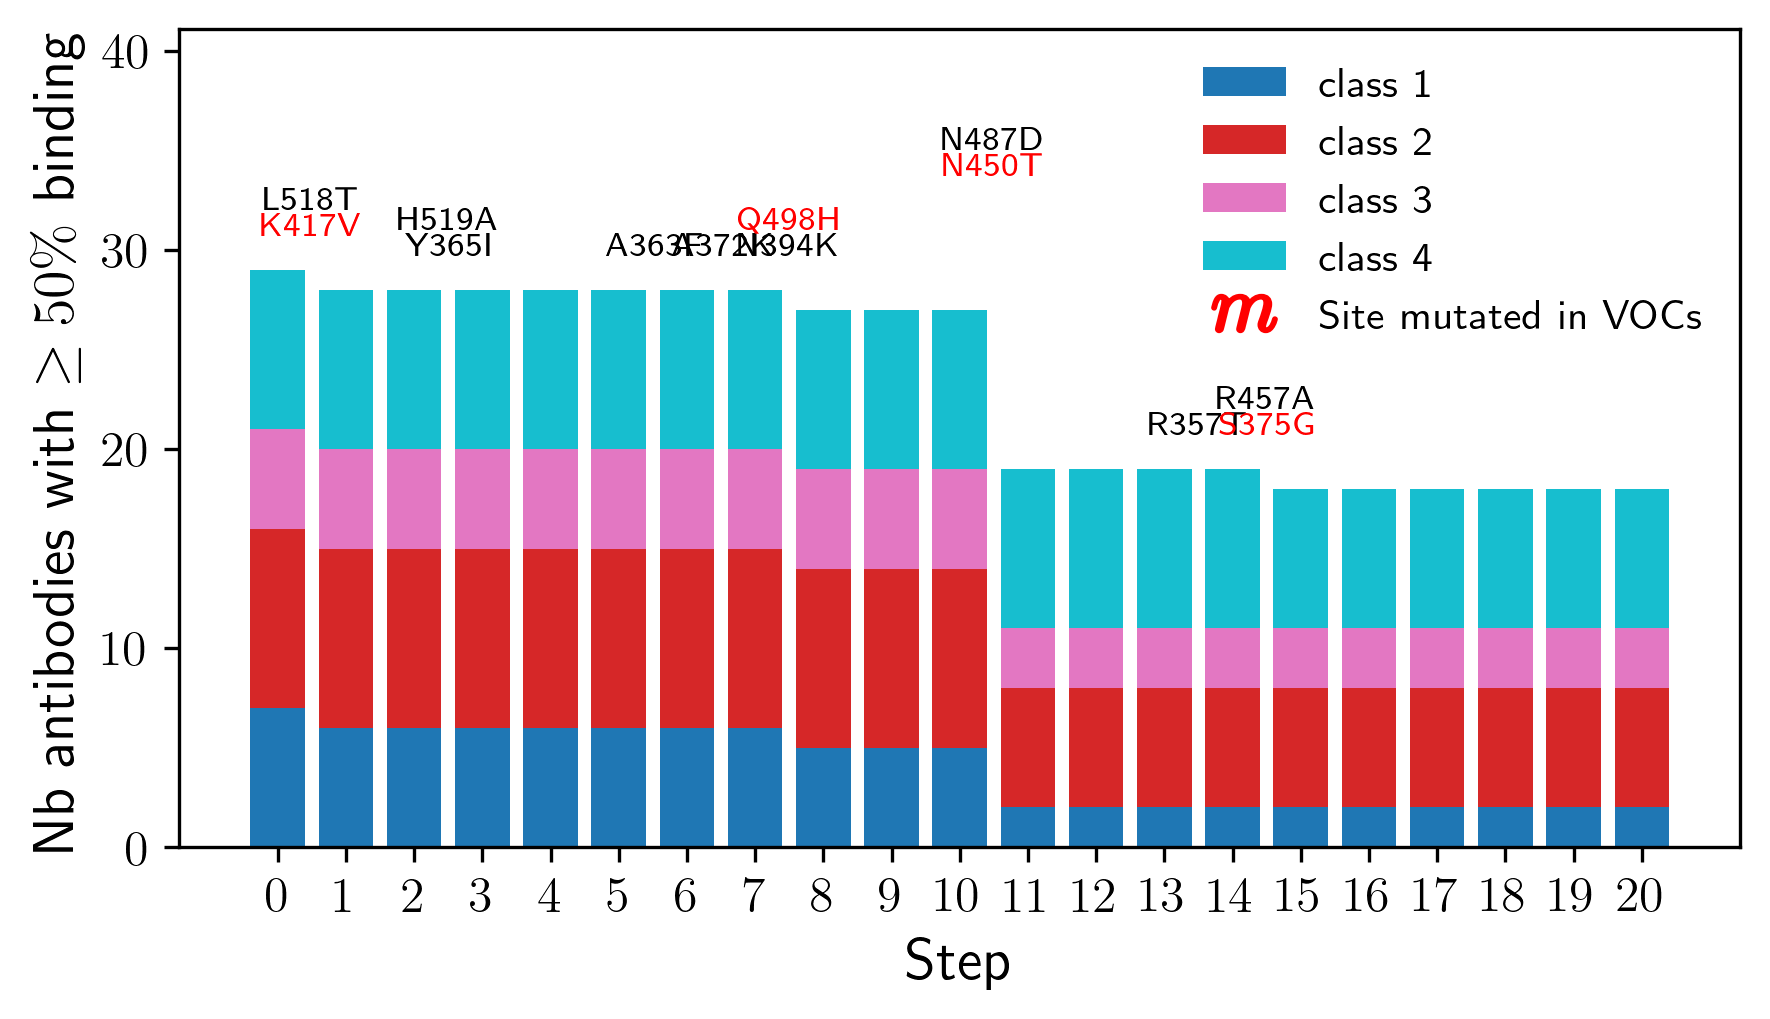

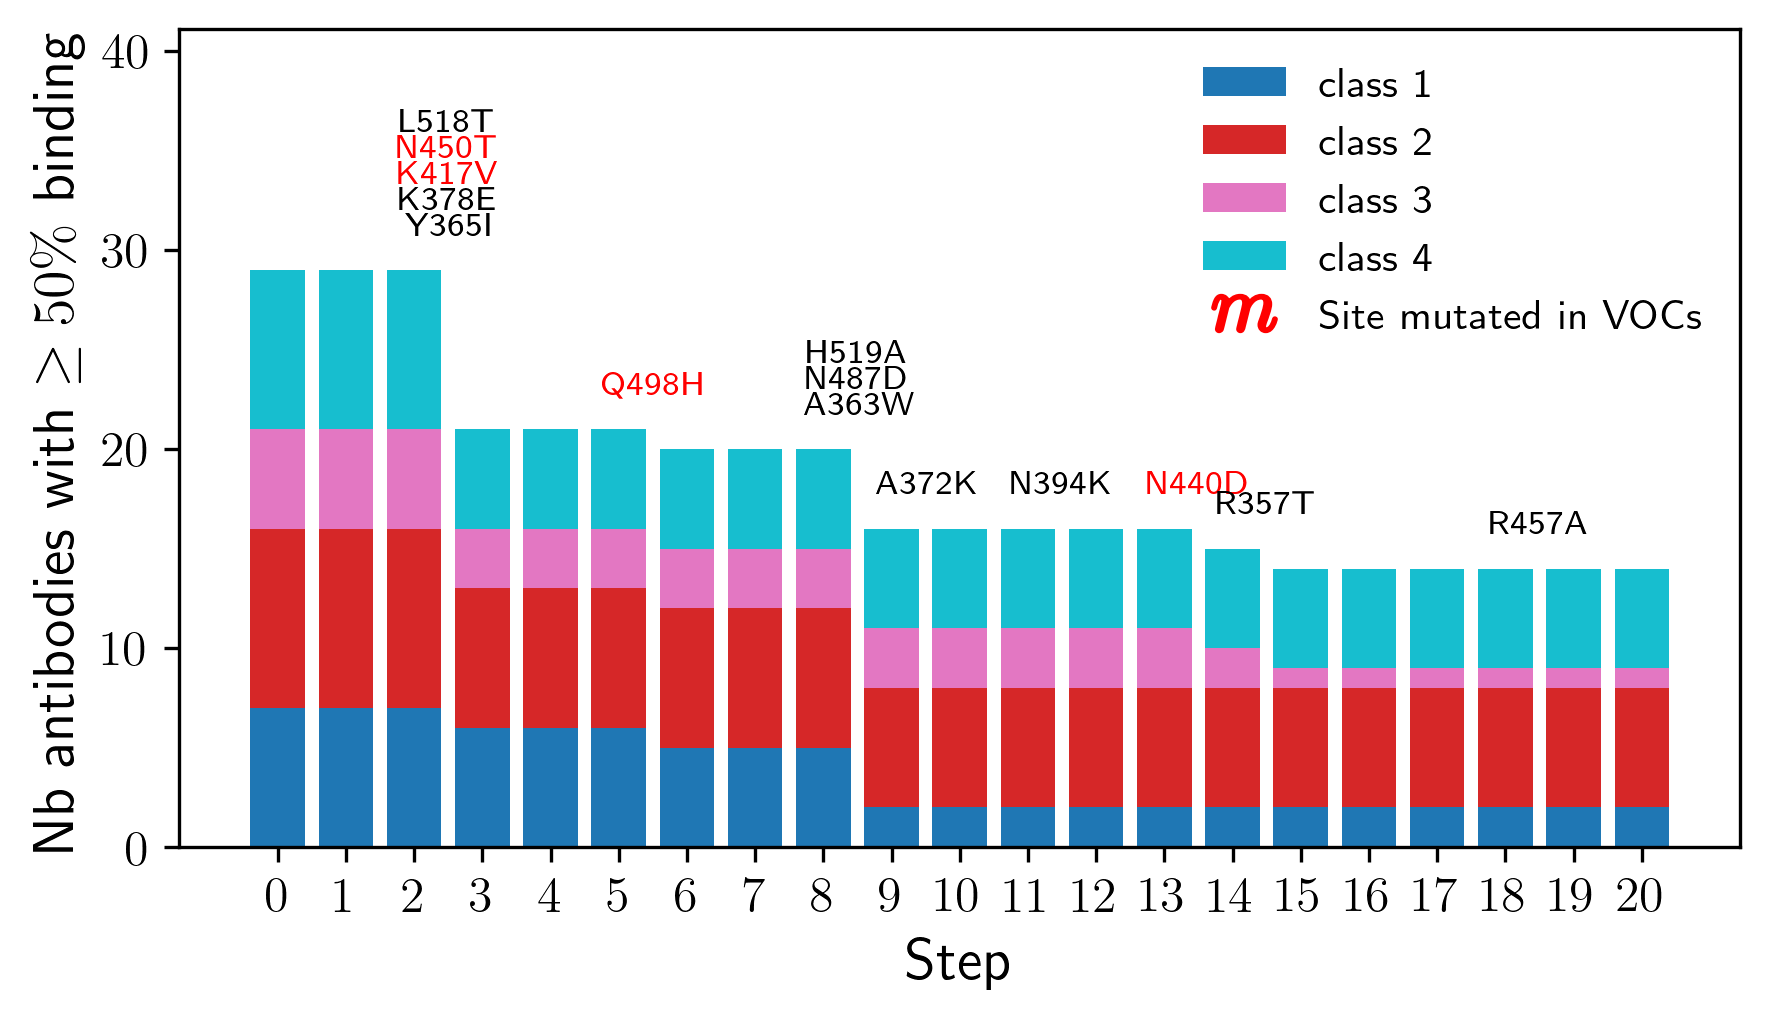

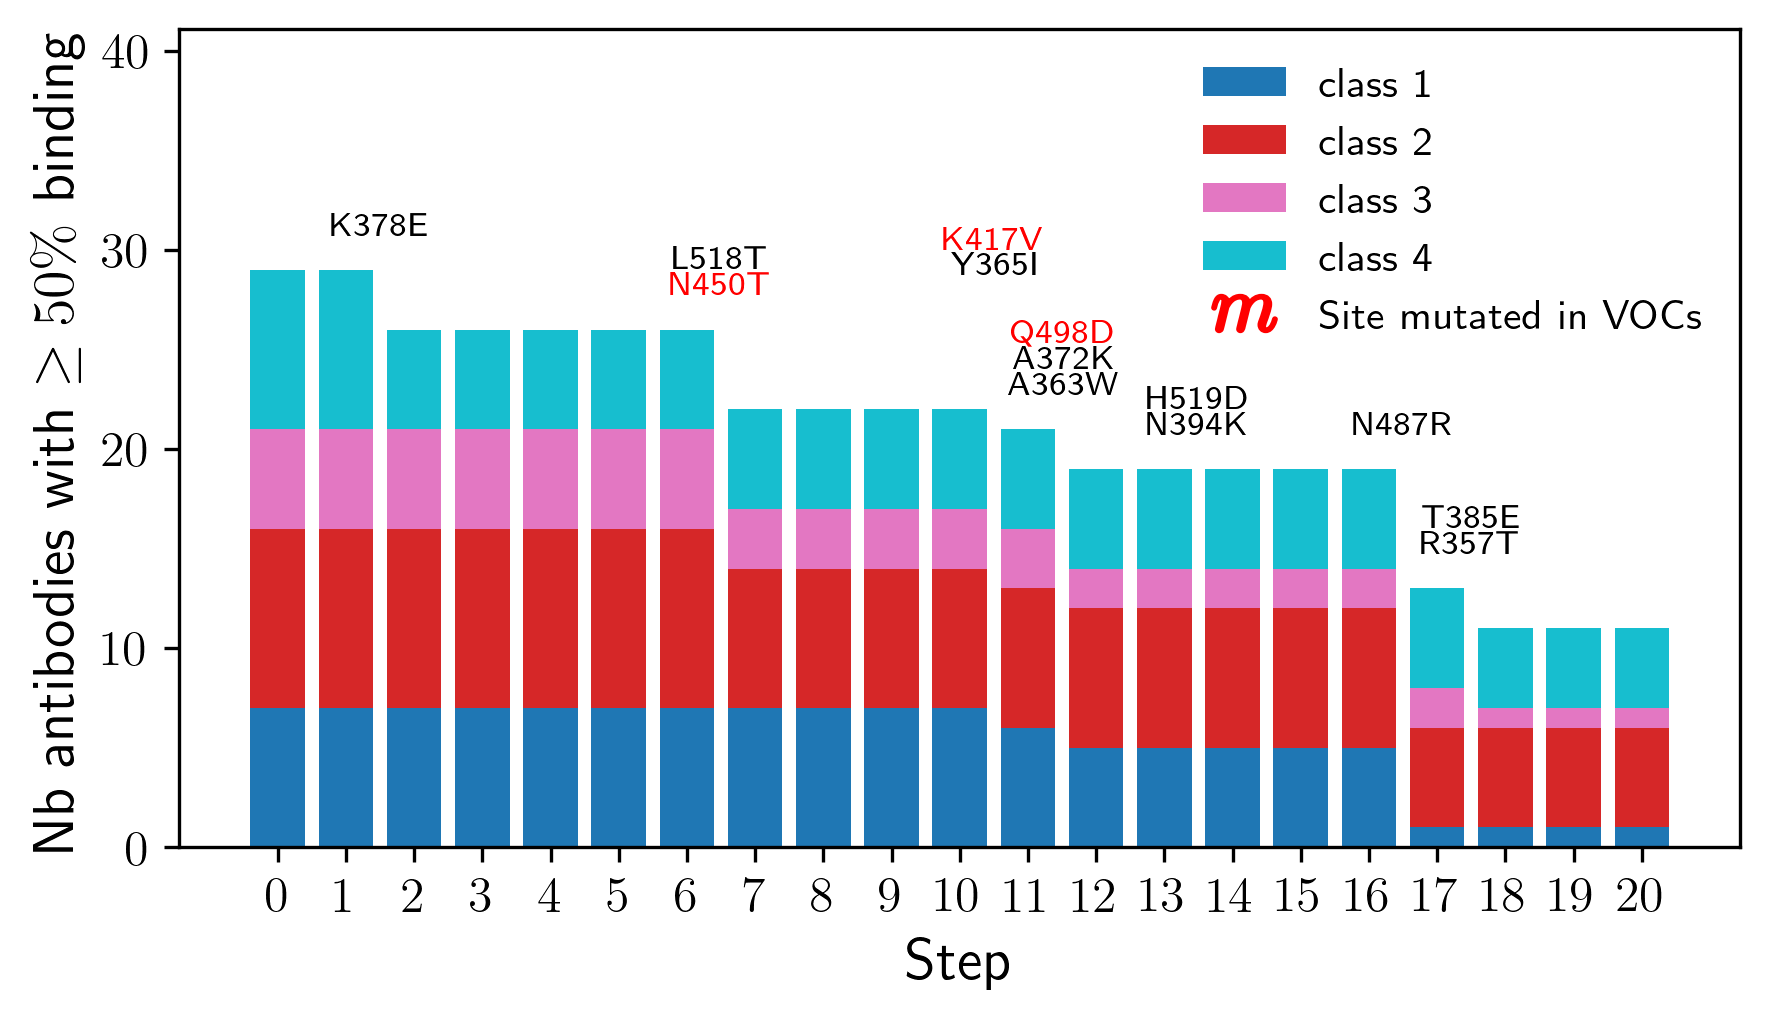

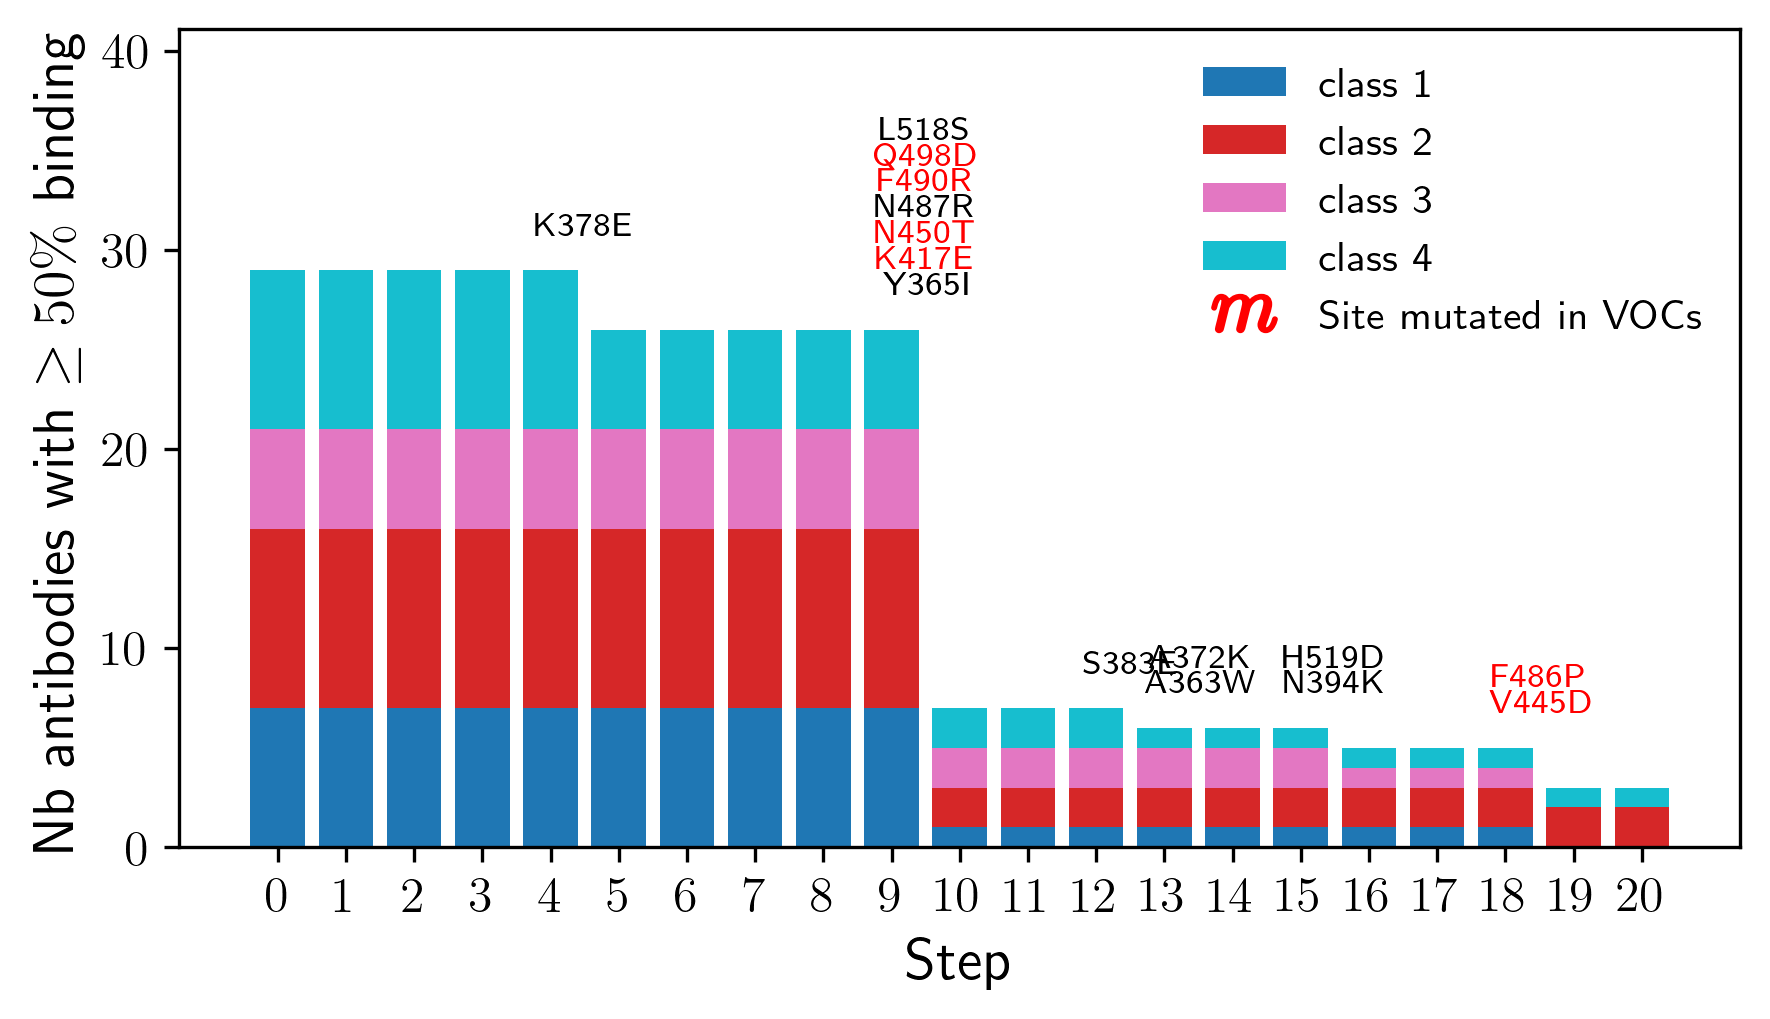

In [35]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re  # Added for robust number extraction
from collections import defaultdict

# --- VOC Mutations List (from your description) ---
VOCS_MUTS = [
    332, 339, 346, 356, 368, 371, 373, 375, 376, 403, 405, 408, 417, 
    440, 444, 445, 446, 450, 452, 455, 456, 460, 477, 478, 481, 484,
    486, 490, 493, 496, 498, 501, 505
]

# Define threshold
TH = np.log(0.5)

# Load antibody classification
ab_class_df = pd.read_csv("../covid/exp_data/bloom_ab_classification/ab_classification.csv")

# Map ab name to class
ab_names = list(ESCAPE_VECTORS.keys())
ab_to_class = dict(zip(ab_class_df['condition'], ab_class_df['condition_subtype']))

# Group indices of antibodies by class
class_to_indices = defaultdict(list)
for i, ab in enumerate(ab_names):
    ab_class = ab_to_class.get(ab)
    if ab_class:
        class_to_indices[ab_class].append(i)

# Sort classes for consistent plotting order
class_to_indices = dict(sorted(class_to_indices.items()))

for path_idx, path in enumerate(paths):
    path_proba = np.load(dir + path)  # Load path data
    path_proba = np.argmax(path_proba, axis=0)

    # Calculate escapes (shape: steps, n_antibodies)
    escapes = np.array([get_log_bindings(path_proba[i]) for i in range(path_proba.shape[0])])

    # 1. Convert every row of path_proba to a sequence string
    seqs = [Proteins_utils.num2seq(row) for row in path_proba]

    # 2. Collect mutation labels for each step
    mut_per_step = [""]
    for i in range(1, len(seqs)):
        prev, curr = seqs[i - 1], seqs[i]
        muts = [
            f"{a_old}{348+pos}{a_new}"
            for pos, (a_old, a_new) in enumerate(zip(prev, curr), start=1)
            if a_old != a_new
        ]
        # Join with newline for vertical stacking
        mut_per_step.append("\n".join(muts))

    # 3. Calculate active antibodies per class (Count where log binding > TH)
    active_abs = escapes > TH  # Boolean mask
    
    active_counts_per_class = {}
    for ab_class, indices in class_to_indices.items():
        # Sum active antibodies for this class at each step
        active_counts_per_class[ab_class] = np.sum(active_abs[:, indices], axis=1)

    # 4. Plot stacked bar chart
    plt.figure(figsize=(6, 3.5), dpi=300)
    steps = np.arange(path_proba.shape[0])
    bottoms = np.zeros(len(steps))
    
    # Use a colormap if you have many classes
    colors = plt.cm.get_cmap('tab10', len(active_counts_per_class))
    
    for i, (ab_class, counts) in enumerate(active_counts_per_class.items()):
        plt.bar(steps, counts, bottom=bottoms, label=ab_class, color=colors(i))
        bottoms += counts  # Update bottoms for the next layer

    # 5. Annotate mutations vertically between steps
    # bottoms now contains the total height of the bars at each step
    total_heights = bottoms
    y_padding = (np.max(total_heights) if np.max(total_heights) > 0 else 1) * 0.05
    # Calculate a specific height for each line of text
    text_line_height = y_padding * 0.9

    for s in range(1, len(mut_per_step)):
        if mut_per_step[s]:
            # Position: between step s-1 and s
            x_pos = s - 0.5
            # Base Height: max of the two adjacent bars + padding
            y_base = max(total_heights[s-1], total_heights[s]) + y_padding
            
            # --- UPDATED COLOR LOGIC ---
            # Split the stacked string back into individual lines
            mut_lines = mut_per_step[s].split('\n')
            
            for i, mut in enumerate(mut_lines):
                # Use regex to find the site number (handles 3 or 4 digits)
                match = re.search(r'(\d+)', mut)
                site_num = int(match.group(1)) if match else -1
                
                # Check if this specific mutation is in VOCs
                if site_num in VOCS_MUTS:
                    text_color = 'red'
                else:
                    text_color = 'black'

                # Plot the individual line, stacking them manually
                if s==11:
                    plt.text(
                        x_pos, 
                        y_base + (i * text_line_height+5), 
                        mut,
                        ha="center", va="bottom",
                        fontsize=8, 
                        color=text_color, 
                        fontweight='bold'
                    )
                else:
                    plt.text(
                        x_pos, 
                        y_base + (i * text_line_height), 
                        mut,
                        ha="center", va="bottom",
                        fontsize=8, 
                        color=text_color, 
                        fontweight='bold'
                    )

    # 6. Nature-ready formatting
    plt.xlabel("Step", fontsize=14)
    plt.ylabel(r"Nb antibodies with $\geq 50\%$ binding", fontsize=14)
    # plt.title(f"Active Antibodies (At least 50\% binding) \n{labels[path_idx]}")
    
    # Legend handling
    handles, labels_legend = plt.gca().get_legend_handles_labels()
    
    # Create the custom Red Marker for the legend
    red_text = plt.Line2D(
        [0], [0], 
        color='red', 
        marker='$m$',   # The $...$ syntax turns the string into a marker
        linestyle='None', 
        markersize=15,    # Increase size so the text is readable
        label='Site mutated in VOCs'
    )    
    handles.append(red_text)
    plt.legend(handles=handles, frameon=False)
    
    # Remove top and right spines
    ax = plt.gca()
    # ax.spines['top'].set_visible(False)
    # ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=12)
    # plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.xticks(steps)
    
    # Adjust Y-limits to make room for the stacked mutation text
    current_ylim = plt.ylim()[1]
    plt.ylim(0, current_ylim * 1.35) # Increase upper limit by 35%

    plt.tight_layout()
    plt.show()


# Most probable sequence start BA.1

In [ ]:
wt_seq=WT[BEGIN:-END]
D=1
dir = '../mean_field_theory/results_scripts/covid_D_20_ba1/'
paths=[f'ba1_mean_f_free_ab_beta_ab_0_D_{D}.npy', f'ba1_mean_f_free_ab_beta_ab_1_D_{D}.npy', f'ba1_mean_f_free_ab_beta_ab_5_D_{D}.npy', f'ba1_mean_f_free_ab_beta_ab_10_D_{D}.npy']
labels=['beta_Ab=0','beta_Ab=1','beta_Ab=5' , 'beta_Ab=10']

In [ ]:
VOCS_MUTS_POST_BA1=[332, 346, 356, 368, 376, 403, 405, 408,  444, 445, 450, 452, 455, 456, 460, 481, 486, 490]

<>:96: SyntaxWarning: invalid escape sequence '\%'
<>:96: SyntaxWarning: invalid escape sequence '\%'
C:\Users\maria\AppData\Local\Temp\ipykernel_18580\529035368.py:96: SyntaxWarning: invalid escape sequence '\%'
  plt.title(f"BA1 start, active Antibodies (At least 50\% binding) \n{labels[path_idx]}")
C:\Users\maria\AppData\Local\Temp\ipykernel_18580\529035368.py:61: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(active_counts_per_class))


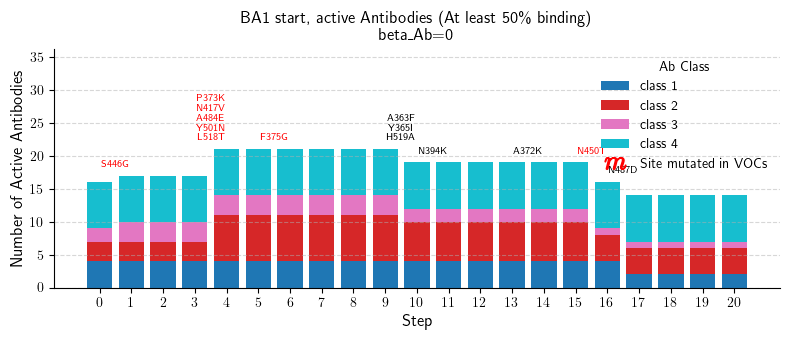

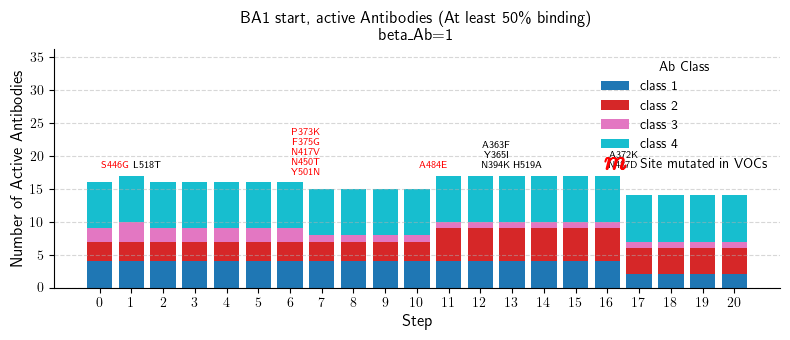

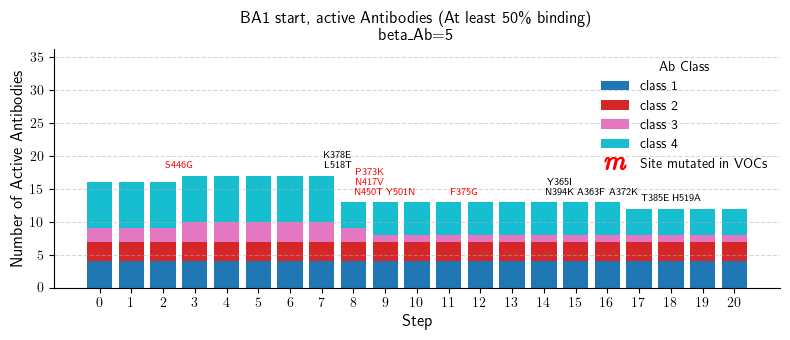

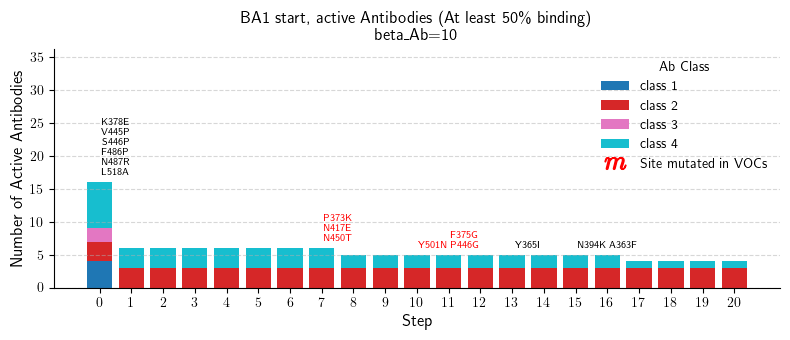

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import defaultdict
# Define threshold
TH = np.log(0.5)

# Load antibody classification
ab_class_df = pd.read_csv("../covid/exp_data/bloom_ab_classification/ab_classification.csv")

# Map ab name to class
ab_names = list(ESCAPE_VECTORS.keys())
ab_to_class = dict(zip(ab_class_df['condition'], ab_class_df['condition_subtype']))

# Group indices of antibodies by class
class_to_indices = defaultdict(list)
for i, ab in enumerate(ab_names):
    ab_class = ab_to_class.get(ab)
    if ab_class:
        class_to_indices[ab_class].append(i)

# Sort classes for consistent plotting order
class_to_indices = dict(sorted(class_to_indices.items()))

for path_idx, path in enumerate(paths):
    path_proba = np.load(dir + path)  # Load path data
    path_proba = np.argmax(path_proba, axis=0)

    # Calculate escapes (shape: steps, n_antibodies)
    escapes = np.array([get_log_bindings(path_proba[i]) for i in range(path_proba.shape[0])])

    # 1. Convert every row of path_proba to a sequence string
    seqs = [Proteins_utils.num2seq(row) for row in path_proba]

    # 2. Collect mutation labels for each step
    mut_per_step = [""]
    for i in range(1, len(seqs)):
        prev, curr = seqs[i - 1], seqs[i]
        muts = [
            f"{a_old}{348+pos}{a_new}"
            for pos, (a_old, a_new) in enumerate(zip(prev, curr), start=1)
            if a_old != a_new
        ]
        # Join with newline for vertical stacking
        mut_per_step.append("\n".join(muts))

    # 3. Calculate active antibodies per class (Count where log binding > TH)
    active_abs = escapes > TH  # Boolean mask
    
    active_counts_per_class = {}
    for ab_class, indices in class_to_indices.items():
        # Sum active antibodies for this class at each step
        active_counts_per_class[ab_class] = np.sum(active_abs[:, indices], axis=1)

    # 4. Plot stacked bar chart
    plt.figure(figsize=(8, 3.5))
    steps = np.arange(path_proba.shape[0])
    bottoms = np.zeros(len(steps))
    
    # Use a colormap if you have many classes
    colors = plt.cm.get_cmap('tab10', len(active_counts_per_class))
    
    for i, (ab_class, counts) in enumerate(active_counts_per_class.items()):
        plt.bar(steps, counts, bottom=bottoms, label=ab_class, color=colors(i))
        bottoms += counts  # Update bottoms for the next layer

    # 5. Annotate mutations vertically between steps
    # bottoms now contains the total height of the bars at each step
    total_heights = bottoms
    y_padding = (np.max(total_heights) if np.max(total_heights) > 0 else 1) * 0.05

    for s in range(1, len(mut_per_step)):
        if mut_per_step[s]:
            # Position: between step s-1 and s
            x_pos = s - 0.5
            # Height: max of the two adjacent bars + padding
            y_pos = max(total_heights[s-1], total_heights[s]) + y_padding
            if int(mut_per_step[s][1:4]) in VOCS_MUTS:
                plt.text(
                    x_pos, y_pos,
                    mut_per_step[s],
                    ha="center", va="bottom",
                    fontsize=7, color='red', fontweight='bold'
                )
            else:
                plt.text(
                    x_pos, y_pos,
                    mut_per_step[s],
                    ha="center", va="bottom",
                    fontsize=7, fontweight='bold'
                )

    # 6. Nature-ready formatting
    plt.xlabel("Step", fontsize=12)
    plt.ylabel("Number of Active Antibodies", fontsize=12)
    plt.title(f"BA1 start, active Antibodies (At least 50\% binding) \n{labels[path_idx]}")
    #add red bold title for mutations in vocs
    handles, labels_legend = plt.gca().get_legend_handles_labels()
    #write mut in legend
    red_text = plt.Line2D(
        [0], [0], 
        color='red', 
        marker='$m$',   # The $...$ syntax turns the string into a marker
        linestyle='None', 
        markersize=15,    # Increase size so the text is readable
        label='Site mutated in VOCs'
    )    
    handles.append(red_text)
    plt.legend(handles=handles, frameon=False, title="Ab Class", loc='upper right')
     # Legend outside to prevent blocking data
    # plt.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc='upper left', title="Ab Class")
    
    # Remove top and right spines
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.xticks(steps)
    
    # Adjust Y-limits to make room for the mutation text
    # We check the transform limits or just add a generous buffer
    plt.ylim(0, 29 * 1.25)

    plt.tight_layout()
    plt.show()

# Comparison BA1 vs WT start

C:\Users\maria\AppData\Local\Temp\ipykernel_18580\2818433659.py:34: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10')(np.linspace(0, 1, n_classes))


Generating separate plots for Betas: [0, 5, 10] (D=1)...


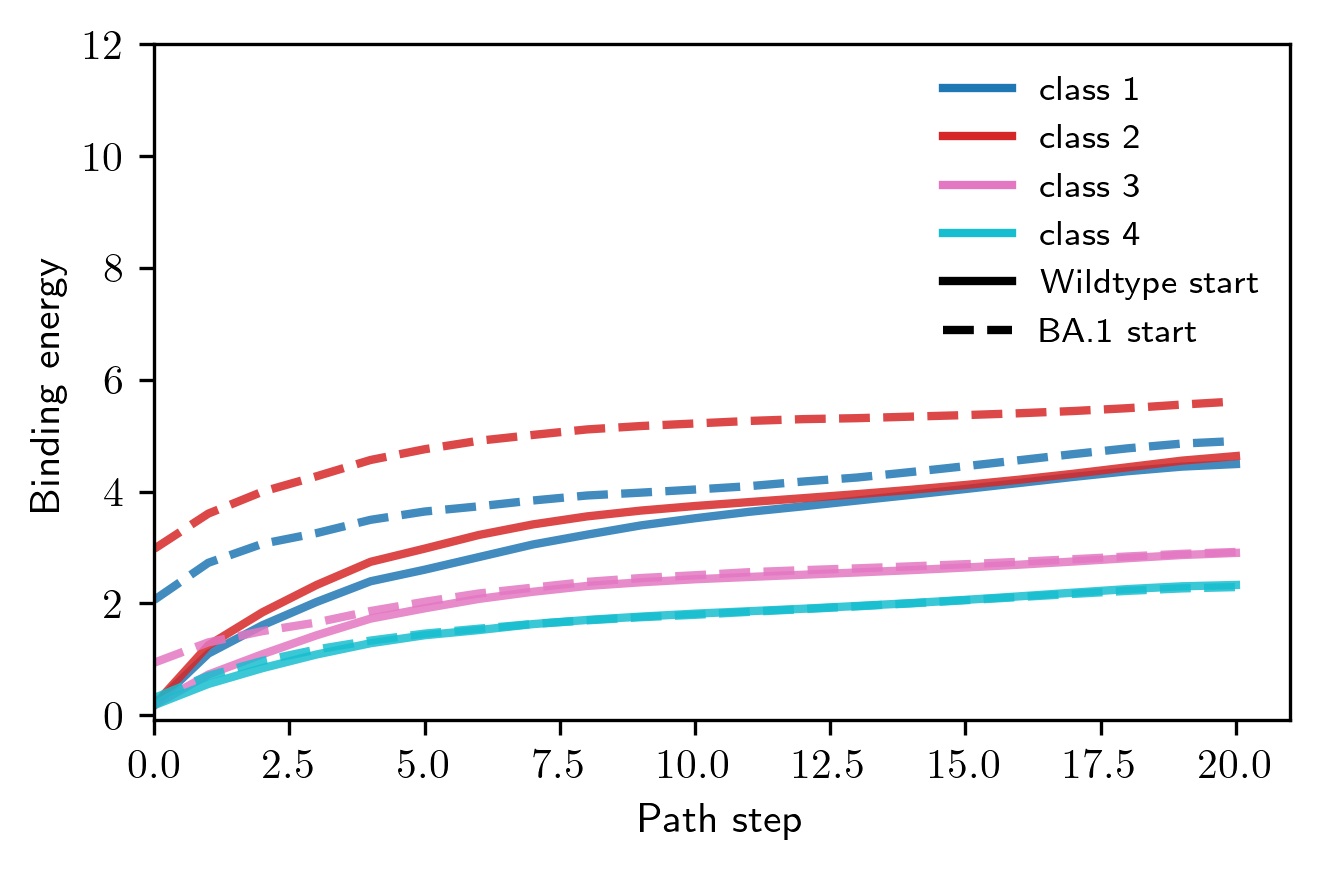

In [ ]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# -----------------------------------------------------------------------------
# 1. SETUP & CONFIGURATION
# -----------------------------------------------------------------------------

dir_wt  = 'results_scripts/covid_D_20/'
dir_ba1 = 'results_scripts/covid_D_20_ba1/'

# Parameters
BETA_ABs = [0, 5, 10]
D_FIXED = 1

# -----------------------------------------------------------------------------
# 2. DATA PRE-REQUISITES (Safety Check)
# -----------------------------------------------------------------------------
try:
    _ = class_to_indices
    _ = ab_names
except NameError:
    # --- DUMMY DATA (Only used if you run this alone) ---
    print("(!) Context variables missing. Using dummy data.")
    ab_names = [f"Ab_{i}" for i in range(10)]
    class_to_indices = {"Class 1": [0,1,2], "Class 2": [3,4,5], "Class 3": [6,7,8]}

classes = sorted([c for c, idxs in class_to_indices.items() if len(idxs) > 0])
n_classes = len(classes)

# Generate consistent colors for the classes
colors = plt.cm.get_cmap('tab10')(np.linspace(0, 1, n_classes))
color_map = {cls: colors[i] for i, cls in enumerate(classes)}

# -----------------------------------------------------------------------------
# 3. HELPER FUNCTIONS
# -----------------------------------------------------------------------------

def extract_parameters(path):
    beta_ab_match = re.search(r'beta_ab_(\d+(?:\.\d+)?)', path)
    D_match = re.search(r'D_(\d+)', path)
    return {
        "beta_ab": float(beta_ab_match.group(1)) if beta_ab_match else None,
        "D": int(D_match.group(1)) if D_match else None,
    }

def find_folder(root_dir, target_beta, target_D):
    if not os.path.exists(root_dir):
        return None
    for d in os.listdir(root_dir):
        full_path = os.path.join(root_dir, d)
        if os.path.isdir(full_path):
            params = extract_parameters(d)
            if (params["beta_ab"] is not None and 
                np.isclose(params["beta_ab"], target_beta) and 
                params["D"] == target_D):
                return full_path
    return None

def process_binding_data(folder_path):
    mopt_path = os.path.join(folder_path, "mopt.npy")
    if not os.path.exists(mopt_path):
        return None, 0

    mopt = np.load(mopt_path)[:, :len(ab_names)]
    n_steps = mopt.shape[0]
    
    class_series = {}
    for cls in classes:
        idxs = class_to_indices[cls]
        if len(idxs) == 0:
            class_series[cls] = np.full(n_steps, np.nan)
        else:
            class_log_data = mopt[:, idxs]
            avg_binding = np.mean(class_log_data, axis=1)
            class_series[cls] = avg_binding
            
    return class_series, n_steps

# -----------------------------------------------------------------------------
# 4. PLOTTING LOOP
# -----------------------------------------------------------------------------

variants = [
    ("Wildtype", dir_wt, "-"),    # Solid
    ("BA1",      dir_ba1, "--")   # Dashed
]

print(f"Generating separate plots for Betas: {BETA_ABs} (D={D_FIXED})...")

for beta in BETA_ABs:
    if beta!=5:
        continue
    fig = plt.figure(figsize=(4.5, 3), dpi=300)
    ax = plt.gca()
    
    max_steps_in_plot = 0
    data_found = False

    for variant_label, root_dir, style in variants:
        folder = find_folder(root_dir, beta, D_FIXED)
        
        if folder:
            data, steps = process_binding_data(folder)
            
            if data:
                data_found = True
                max_steps_in_plot = max(max_steps_in_plot, steps)
                x_vals = np.arange(steps)
                
                for cls in classes:
                    y_vals = -data[cls]
                    ax.plot(x_vals, y_vals, 
                             color=color_map[cls], 
                             linestyle=style, 
                             linewidth=2, 
                             alpha=0.85)
        else:
            print(f"  [Warning] Missing {variant_label} folder for Beta={beta}")

    # Styling
    # ax.set_title(f"Binding Energy vs Step ($\\beta_{{ab}} = {beta}$)", fontsize=13)
    ax.set_xlabel("Path step")
    ax.set_ylabel("Binding energy")
    ax.set_ylim(top=12)
    
    if max_steps_in_plot > 0:
        ax.set_xlim(0, max_steps_in_plot)
    
    # ax.grid(True, linestyle=':', alpha=0.6)
    
    # Legend
    if data_found:
        legend_elements = []
        # Header: Classes
        # FIXED: Changed \bf to \mathbf to avoid LaTeX crash
        # legend_elements.append(Line2D([0], [0], color='w', label='Antibody classes'))
        for cls in classes:
            legend_elements.append(Line2D([0], [0], color=color_map[cls], lw=2, label=cls))
        
        # Spacer & Header: Variants
        # legend_elements.append(Line2D([0], [0], color='w', label=' '))
        # # FIXED: Changed \bf to \mathbf
        # legend_elements.append(Line2D([0], [0], color='w', label='Variant start'))
        legend_elements.append(Line2D([0], [0], color='black', lw=2, linestyle='-', label='Wildtype start'))
        legend_elements.append(Line2D([0], [0], color='black', lw=2, linestyle='--', label='BA.1 start'))
        
        ax.legend(handles=legend_elements, loc='best', frameon=False, fontsize='small')
    else:
        ax.text(0.5, 0.5, "No Data Found", ha='center', transform=ax.transAxes)

    # FIXED: Wrapped tight_layout in try-except to prevent runtime crash
    plt.tight_layout()
  
    plt.show()